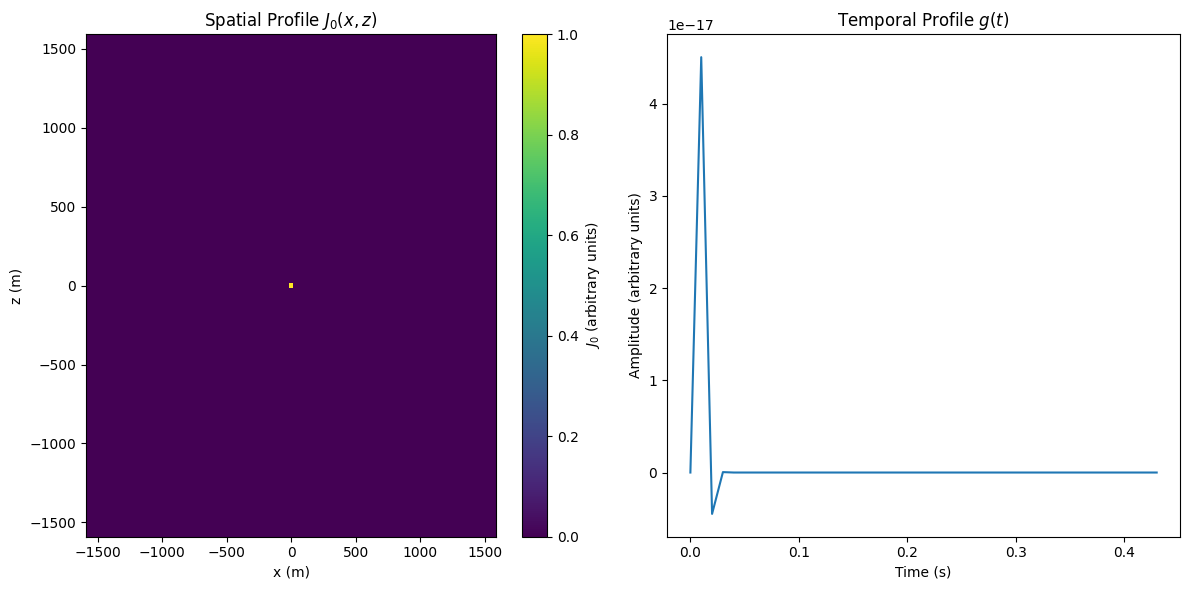

In [98]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
x_min, x_max = -10.0, 10.0  # Spatial domain in x (meters)
z_min, z_max = -10.0, 10.0  # Spatial domain in z (meters)
x_points, z_points = 56, 56  # Grid resolution in x and z
t_min, t_max = 0.0, 0.44  # Time domain (seconds)
dt = 0.01  # Time step (seconds)

# Source parameters
x0, z0 = 0, 0  # Line source location (meters)
f_c = 50  # Central frequency (Hz)
f_cutoff = 2 * f_c  # Cutoff frequency (Hz)
tau = 1 / (2 * f_c)  # Pulse width approximation
amplitude = 1.0  # Amplitude of the source

# Create spatial grid
L = 3150
x = z = np.linspace(-L / 2, L / 2, 105)
X, Z = np.meshgrid(x, z)

# Create spatial profile J_0(x, z)
def spatial_profile(x, z, x0, z0, sigma=0.1):
    """
    Gaussian spatial profile centered at (x0, z0).
    """
    return np.exp(-((x - x0)**2 + (z - z0)**2) / (2 * sigma**2))

J_0 = spatial_profile(X, Z, x0, z0)

# Create temporal profile g(t)
def temporal_profile(t, f_c, tau):
    """
    Modulated sine wave with Gaussian envelope.
    """
    return np.sin(2 * np.pi * f_c * t) * np.exp(-(t / tau)**2)

# Create time array
t = np.arange(t_min, t_max, dt)
g_t = temporal_profile(t, f_c, tau)

# Combine spatial and temporal profiles to create J(x, z, t)
def J(x, z, t):
    """
    Calculate J(x, z, t) by combining spatial and temporal profiles.
    """
    J_spatial = spatial_profile(x, z, x0, z0, sigma=30)
    return np.array([J_spatial * temporal_profile(ti, f_c, tau) for ti in t])

J_t = J(X, Z, t)

# Visualize the spatial and temporal components
plt.figure(figsize=(12, 6))

# Spatial profile
plt.subplot(1, 2, 1)
plt.title("Spatial Profile $J_0(x, z)$")
plt.pcolormesh(X, Z, J_0, shading='auto', cmap='viridis')
plt.colorbar(label="$J_0$ (arbitrary units)")
plt.xlabel("x (m)")
plt.ylabel("z (m)")

# Temporal profile
plt.subplot(1, 2, 2)
plt.title("Temporal Profile $g(t)$")
plt.plot(t, g_t)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (arbitrary units)")

plt.tight_layout()
plt.show()

# Output: J(x, z, t) is now ready for use in your simulation.


In [91]:
np.exp(-((x - x0)**2 + (z - z0)**2) / (2 * 0.01**2))

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])

In [88]:
J_spatial = spatial_profile(x, z, x0, z0, sigma=10**9)
for ti in t:
    test = np.array([J_spatial * temporal_profile(ti, f_c, tau) ])
    print(np.max(test))

0.0
-1.7043577257599703e-31
-4.253894390801033e-78
-4.2842146323646457e-156
-2.0634812033506536e-265
0.0
-0.0
0.0
-0.0
-0.0
0.0
-0.0
-0.0
-0.0
0.0
-0.0
-0.0
-0.0
-0.0
-0.0
0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
0.0
0.0
-0.0
-0.0
-0.0
-0.0
0.0
-0.0
0.0
-0.0
-0.0
-0.0
-0.0
0.0
-0.0
-0.0
-0.0


In [50]:
np.max(J_t)

-0.0

In [ ]:
np.

In [ ]:
plt.plot(np.sin)